In [821]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from datasets import load_dataset

PARTE 1 — CARGA Y EXPLORACIÓN DE DATOS

In [822]:
ds = load_dataset("jskswamy/predictive-maintenance-data")

In [823]:
print(ds.shape)


{'train': (14650, 23), 'validation': (1954, 23), 'test': (2931, 23)}


In [824]:
train_df=ds["train"].to_pandas()
val_df=ds['validation'].to_pandas()
test_df=ds['test'].to_pandas()

In [825]:
train_df.head()

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,168.012736,...,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,0.071094,7.607961,161.419599,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,360.135302,...,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,0.093024,14.922979,152.464814,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,237.550882,...,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,0.073284,10.985159,162.319576,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,342.677654,...,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,0.055722,12.555685,148.415905,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,300.271898,...,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,0.070473,11.703479,162.622677,0


In [826]:
print(f"train: {train_df.shape}")
print(f"val: {val_df.shape}")
print(f"test: {test_df.shape}")

train: (14650, 23)
val: (1954, 23)
test: (2931, 23)


In [827]:
#Concatenar todo en un dataframe 
df=pd.concat([train_df, val_df,test_df], ignore_index=True)

print("Dataset completo:", df.shape)
df.head()

Dataset completo: (19535, 23)


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,168.012736,...,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,0.071094,7.607961,161.419599,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,360.135302,...,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,0.093024,14.922979,152.464814,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,237.550882,...,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,0.073284,10.985159,162.319576,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,342.677654,...,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,0.055722,12.555685,148.415905,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,300.271898,...,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,0.070473,11.703479,162.622677,0


In [828]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Engine RPM                     19535 non-null  int64  
 1   Lub Oil Pressure               19535 non-null  float64
 2   Fuel Pressure                  19535 non-null  float64
 3   Coolant Pressure               19535 non-null  float64
 4   Lub Oil Temp                   19535 non-null  float64
 5   Coolant Temp                   19535 non-null  float64
 6   RPM_x_OilPressure              19535 non-null  float64
 7   RPM_x_FuelPressure             19535 non-null  float64
 8   RPM_x_CoolantPressure          19535 non-null  float64
 9   OilTemp_x_OilPressure          19535 non-null  float64
 10  CoolantTemp_x_CoolantPressure  19535 non-null  float64
 11  RPM_squared                    19535 non-null  int64  
 12  OilPressure_squared            19535 non-null  float64
 1

In [829]:
columnas=df.columns.tolist()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2.239000e+03
Lub Oil Pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566e+00
Fuel Pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,2.113833e+01
Coolant Pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505e+00
Lub Oil Temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,8.958080e+01
Coolant Temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,1.955279e+02
RPM_x_OilPressure,19535.0,2620.923894,1243.143436,1.326572,1739.171156,2383.271067,3265.915016,1.190009e+04
RPM_x_FuelPressure,19535.0,5265.023724,2929.726204,2.715436,3319.939826,4604.612330,6451.679249,3.111816e+04
RPM_x_CoolantPressure,19535.0,1840.907931,1052.535810,1.511984,1127.594910,1588.671030,2280.180318,1.166476e+04
OilTemp_x_OilPressure,19535.0,256.490880,79.881621,0.249275,195.357046,245.395639,315.445690,5.618897e+02


In [830]:
print("Dimensiones del dataset")
print("--"*60)
print(f"Numero de columnas (VARIABLES): {df.shape[1]}")
print(f"Numero de filas (MEDICIONES): {df.shape[0]}")

Dimensiones del dataset
------------------------------------------------------------------------------------------------------------------------
Numero de columnas (VARIABLES): 23
Numero de filas (MEDICIONES): 19535


In [831]:
from pprint import pprint
columnas_enteros=df.select_dtypes(include=int).columns
columnas_float=df.select_dtypes(include=float).columns

print(f"\nNumero de columnas con valores de tipo int:\n{len(columnas_enteros)}: {columnas_enteros}")

print(f"\nNumero de columnas con valores de tipo int:\n{len(columnas_float)}: {columnas_float}")


Numero de columnas con valores de tipo int:
3: Index(['Engine RPM', 'RPM_squared', 'Engine Condition'], dtype='str')

Numero de columnas con valores de tipo int:
20: Index(['Lub Oil Pressure', 'Fuel Pressure', 'Coolant Pressure', 'Lub Oil Temp',
       'Coolant Temp', 'RPM_x_OilPressure', 'RPM_x_FuelPressure',
       'RPM_x_CoolantPressure', 'OilTemp_x_OilPressure',
       'CoolantTemp_x_CoolantPressure', 'OilPressure_squared', 'TempDiff',
       'OilFuelPressureRatio', 'CoolantOilPressureRatio', 'OilHealthIndex',
       'CoolantStress', 'OilTempPerRPM', 'CoolantTempPerRPM', 'PressureSum',
       'TempSum'],
      dtype='str')


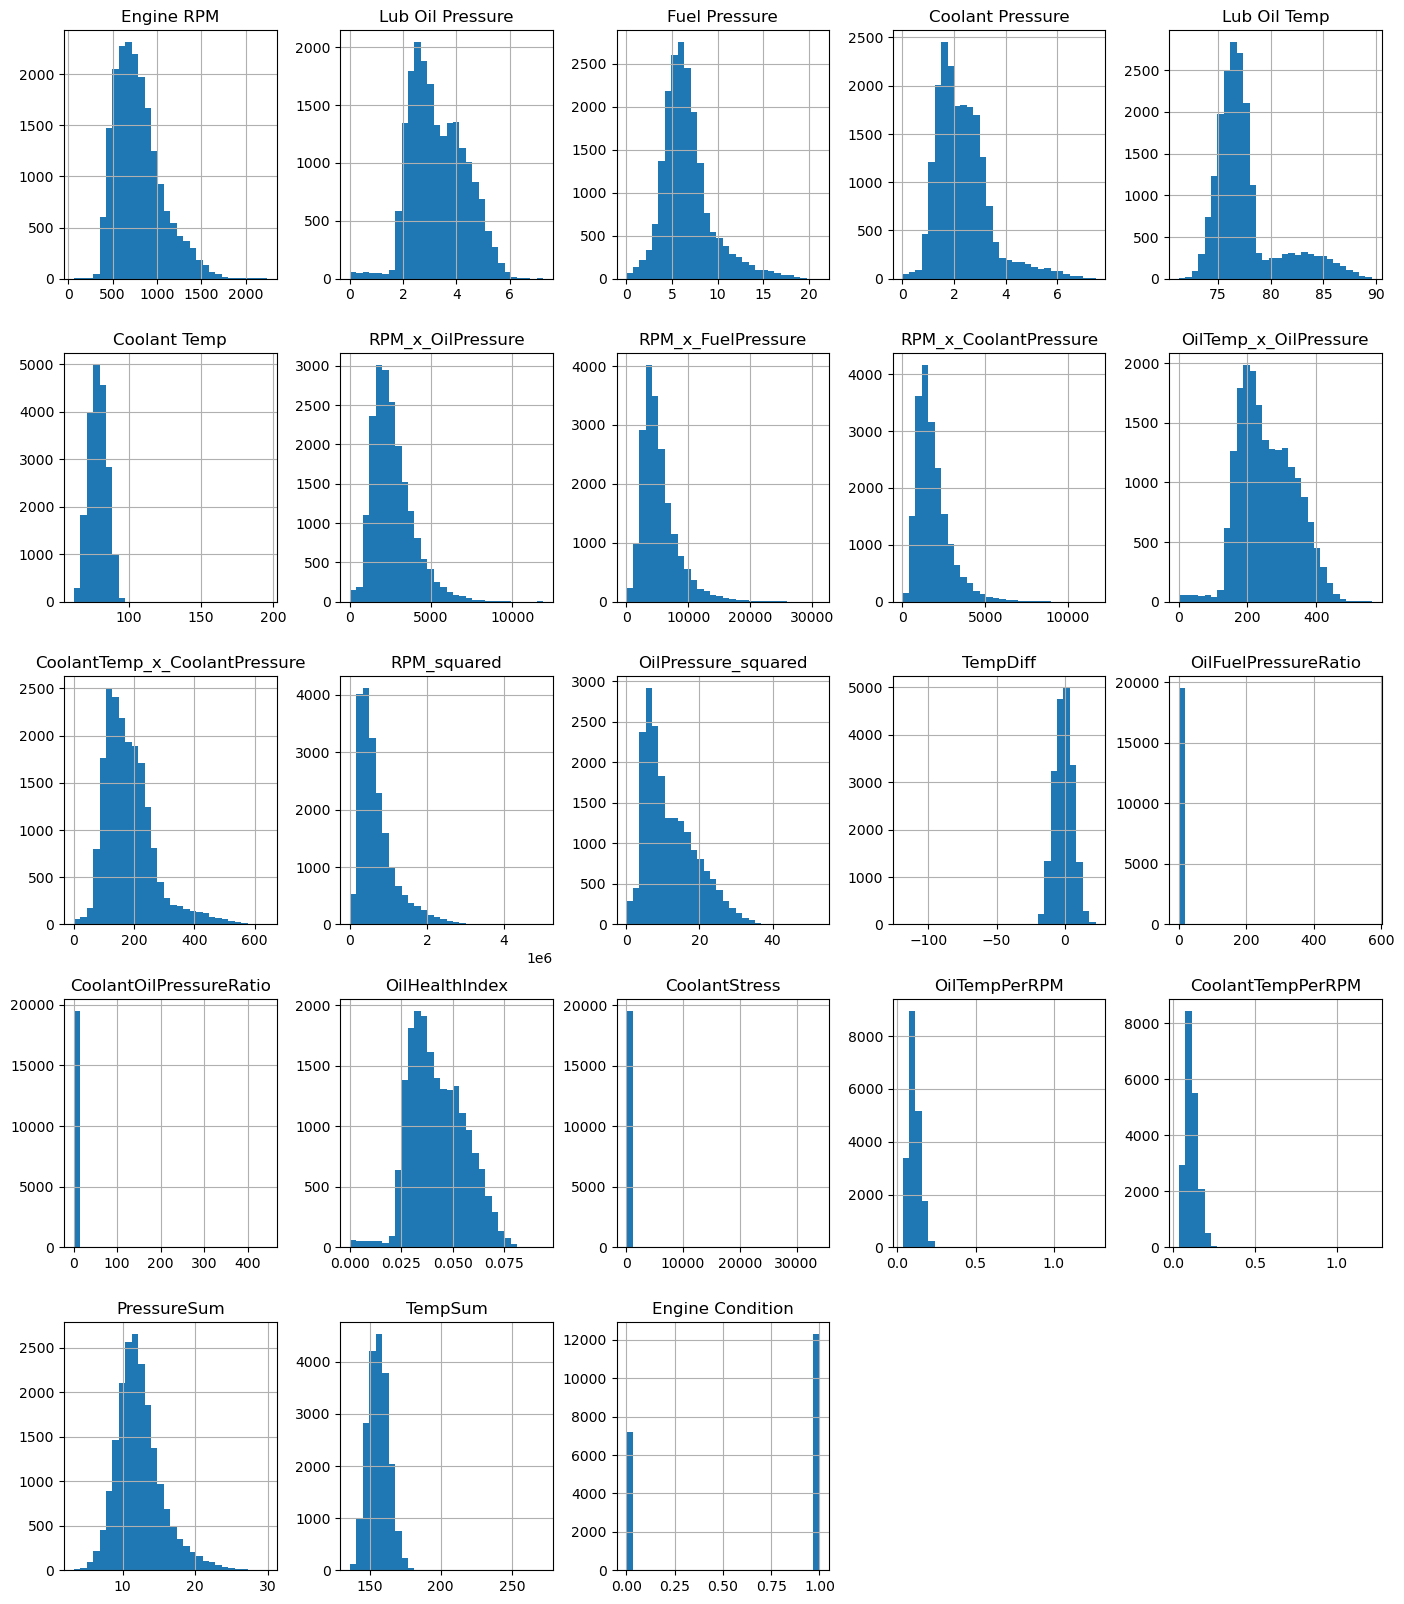

In [832]:
df.hist(bins=30, figsize=(17,20))
plt.show()

In [833]:
df.isnull().sum()

Engine RPM                       0
Lub Oil Pressure                 0
Fuel Pressure                    0
Coolant Pressure                 0
Lub Oil Temp                     0
Coolant Temp                     0
RPM_x_OilPressure                0
RPM_x_FuelPressure               0
RPM_x_CoolantPressure            0
OilTemp_x_OilPressure            0
CoolantTemp_x_CoolantPressure    0
RPM_squared                      0
OilPressure_squared              0
TempDiff                         0
OilFuelPressureRatio             0
CoolantOilPressureRatio          0
OilHealthIndex                   0
CoolantStress                    0
OilTempPerRPM                    0
CoolantTempPerRPM                0
PressureSum                      0
TempSum                          0
Engine Condition                 0
dtype: int64

<Axes: >

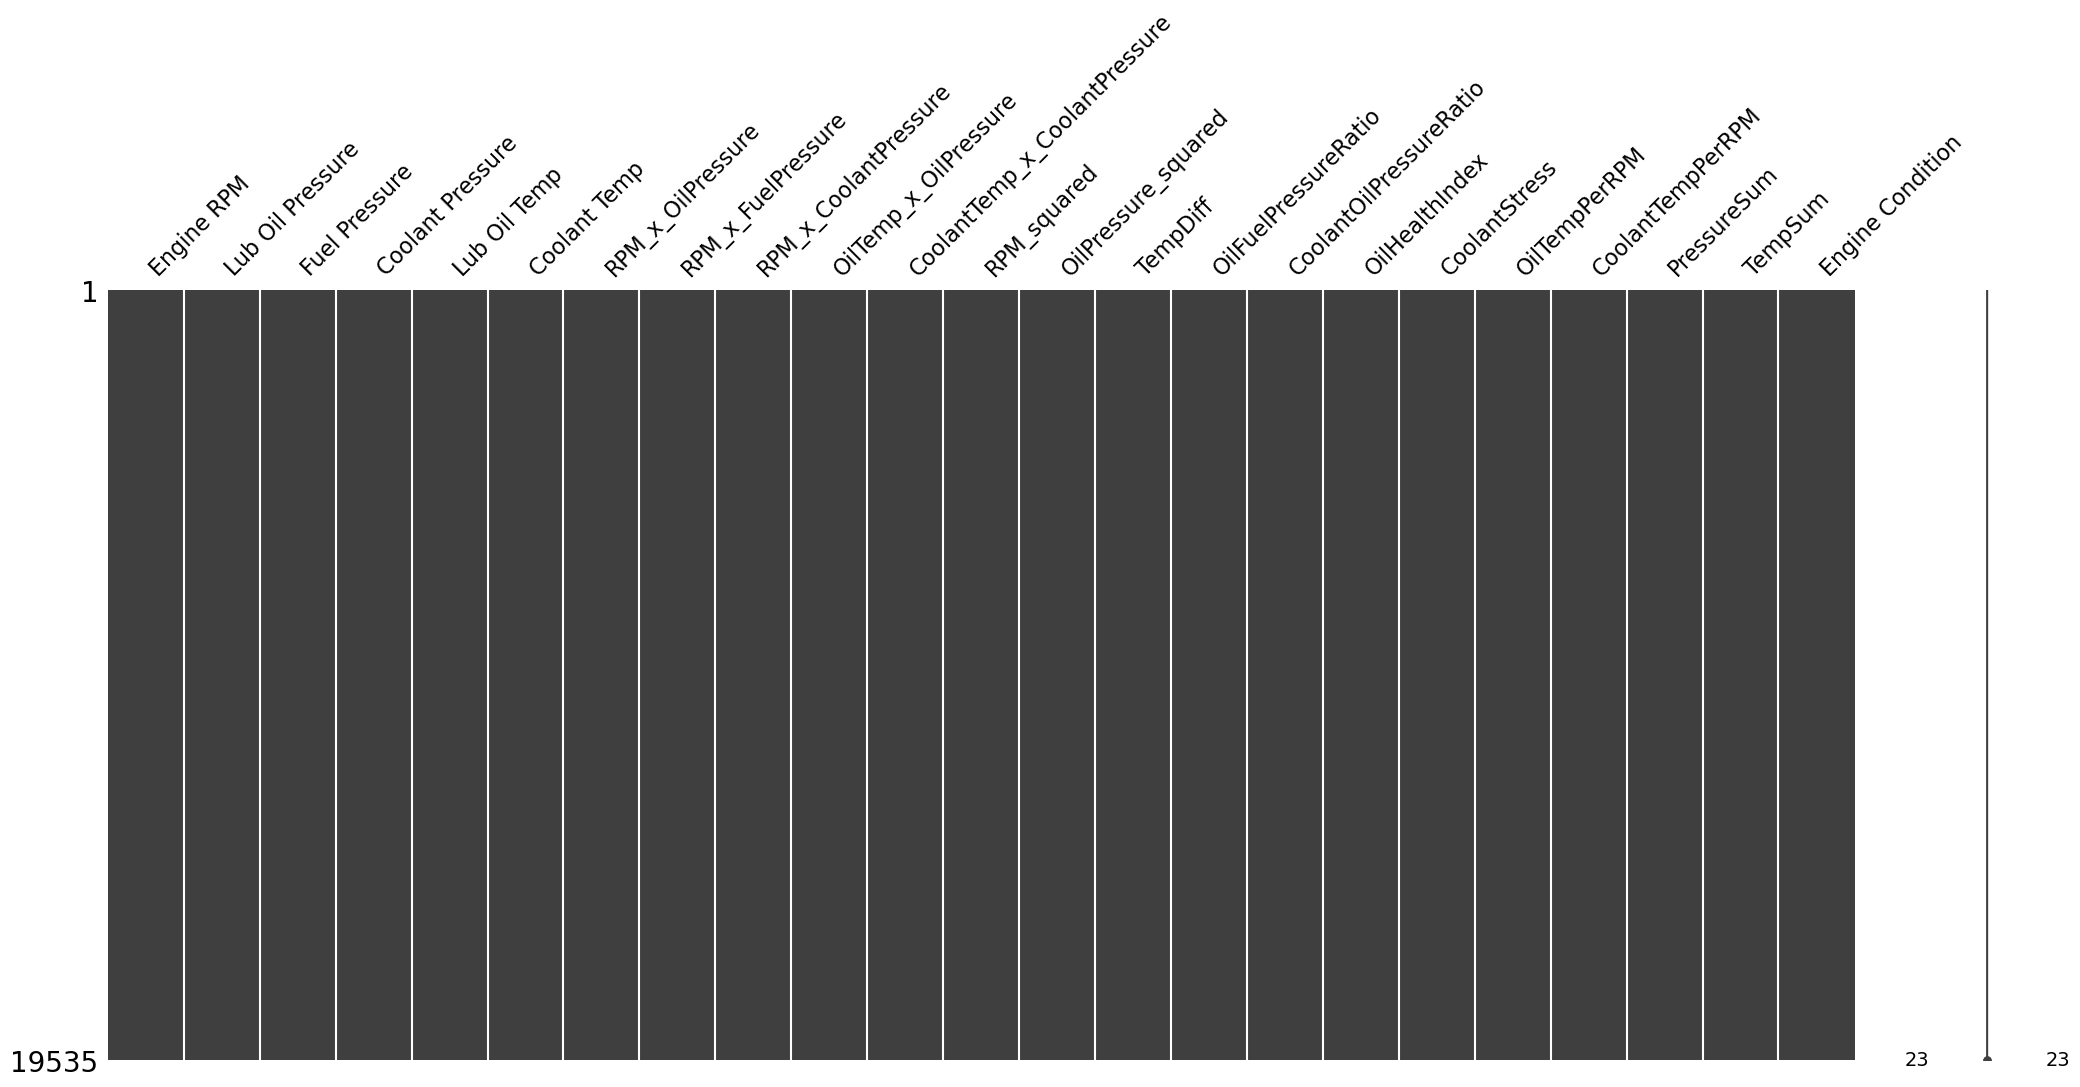

In [834]:
import missingno as msno
msno.matrix(df)


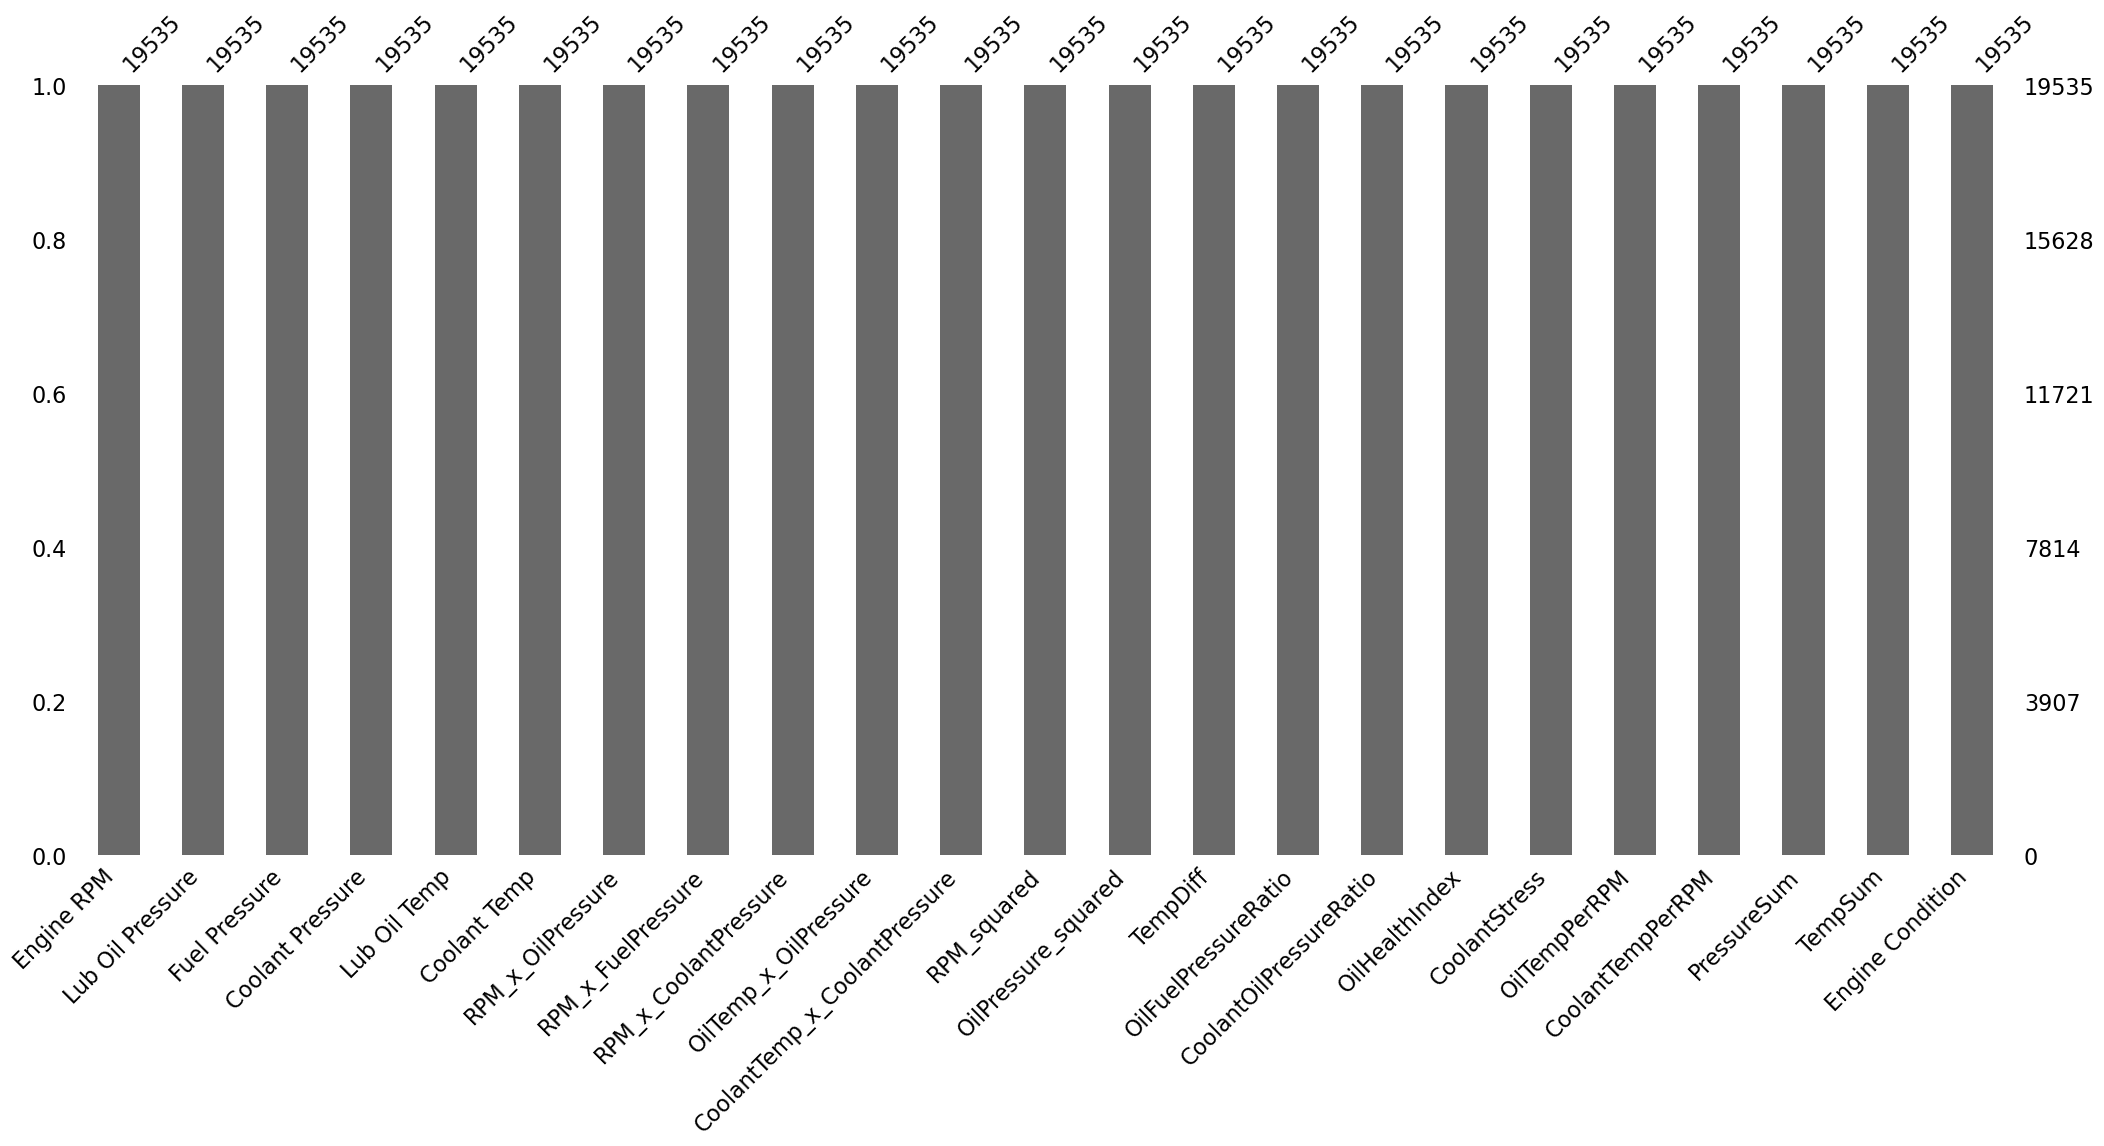

In [835]:
msno.bar(df)
plt.show()

In [836]:
round(df["Engine Condition"].value_counts(normalize=True)*100,2)

Engine Condition
1    63.05
0    36.95
Name: proportion, dtype: float64

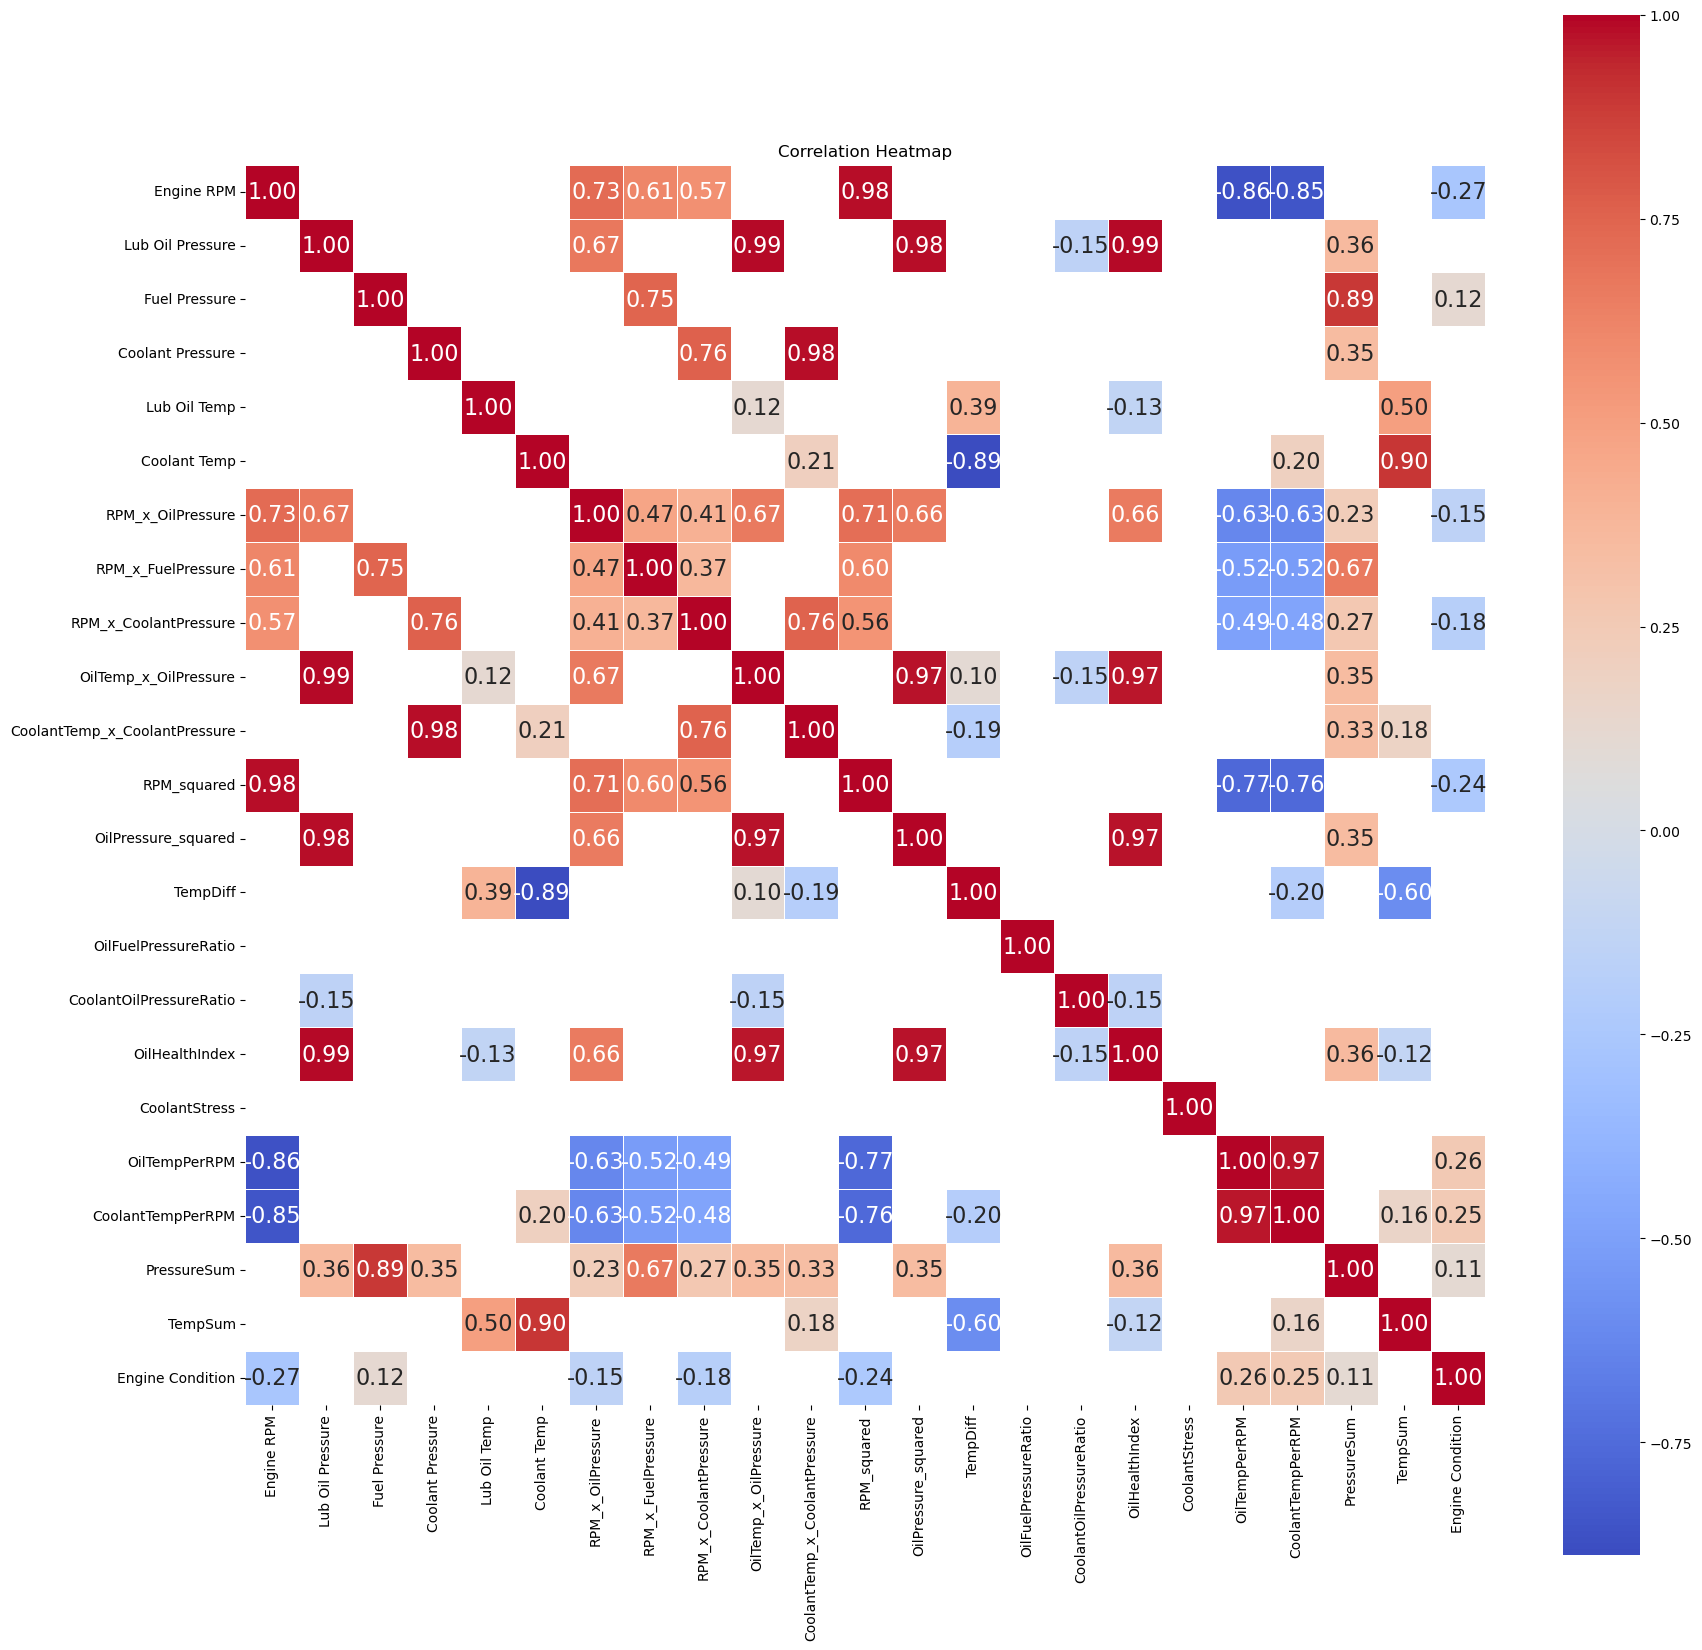

In [837]:
#Existen clases desbalanceadas analizemos correlación entre variables
import seaborn as sns
corr = df.corr(numeric_only=True)

threshold = 0.1

corr_filtrado = corr[(corr.abs() > threshold)]

plt.figure(figsize=(20,20))
sns.heatmap(corr_filtrado,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            annot_kws={"size": 16},
            square=True


            )
plt.title("Correlation Heatmap")
plt.show()

In [838]:
import networkx as nx

# matriz de correlación
corr = df.corr(numeric_only=True)

# threshold
threshold = 0.8

# crear grafo
G = nx.Graph()

# agregar nodos
for col in corr.columns:
    G.add_node(col)

# agregar edges (conexiones)
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])

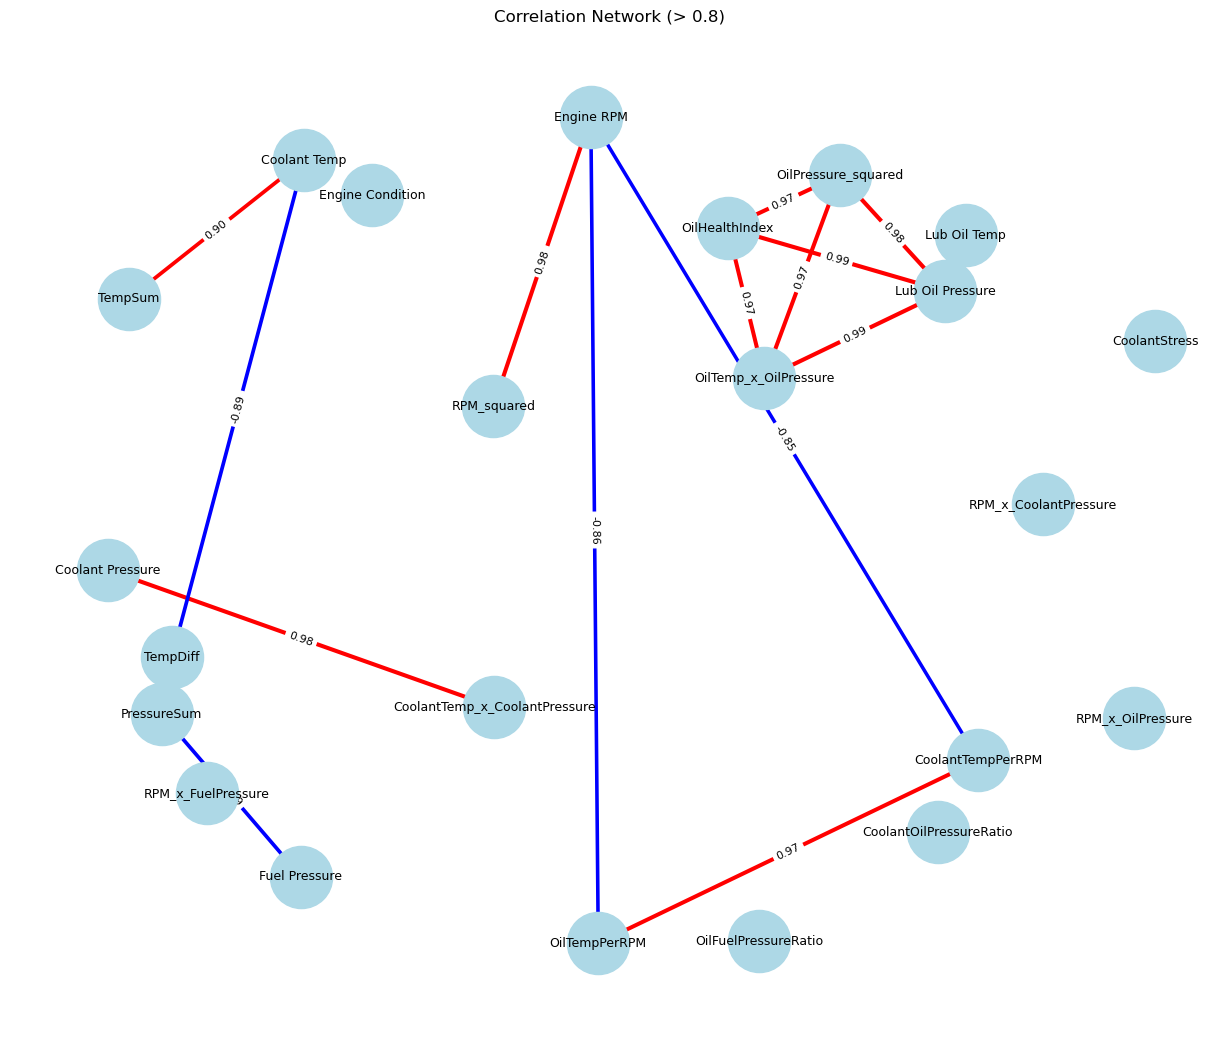

In [839]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=1, weight='weight', seed=42)

edges = G.edges(data=True)

edge_labels = {
    (n1, n2): f"{attr['weight']:.2f}"
    for n1, n2, attr in G.edges(data=True)
}
# colores según correlación
edge_colors = ['red' if abs(e[2]['weight']) > 0.9 else 'blue' for e in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=9,
    edge_color=edge_colors,
    width=weights
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Correlation Network (> 0.8)")
plt.show()

In [840]:
## En base a nuestro grafo y el nivel de correlacion de ciertas variables procedemos a eliminar las variables mas redundantes en este caso mostramos primero las correlaciones mas destacadas:
variables_corr=[]
for  n1, n2, attr in edges: 
    if attr["weight"]>0.9:
        variables_corr.append({"nodo1": n1, "nodo2": n2, "Corr": attr["weight"]})
pd.DataFrame(variables_corr).sort_values(by="Corr", ascending=False)


,nodo1,nodo2,Corr
3,Lub Oil Pressure,OilHealthIndex,0.992065
1,Lub Oil Pressure,OilTemp_x_OilPressure,0.991094
4,Coolant Pressure,CoolantTemp_x_CoolantPressure,0.981856
2,Lub Oil Pressure,OilPressure_squared,0.981376
0,Engine RPM,RPM_squared,0.978712
8,OilPressure_squared,OilHealthIndex,0.974302
6,OilTemp_x_OilPressure,OilPressure_squared,0.971860
7,OilTemp_x_OilPressure,OilHealthIndex,0.966507
9,OilTempPerRPM,CoolantTempPerRPM,0.966199
5,Coolant Temp,TempSum,0.900725


In [841]:
lista_var_redu=["OilPressure_squared", "OilTemp_x_OilPressure", "OilPressure_squared", "CoolantTemp_x_CoolantPressure", "RPM_squared", "CoolantTempPerRPM", "TempSum"]

In [842]:
df.head()

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,168.012736,...,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,0.071094,7.607961,161.419599,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,360.135302,...,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,0.093024,14.922979,152.464814,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,237.550882,...,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,0.073284,10.985159,162.319576,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,342.677654,...,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,0.055722,12.555685,148.415905,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,300.271898,...,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,0.070473,11.703479,162.622677,0


In [843]:
df.drop(columns=lista_var_redu)

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,PressureSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,7.607961,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,14.922979,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,10.985159,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,12.555685,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,11.703479,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19530,1196,2.854665,4.663090,1.856775,77.315182,87.776250,3414.179690,5577.055910,2220.703254,-10.461068,0.612183,0.650435,0.036922,47.273465,0.064645,9.374531,1
19531,788,2.866921,9.449227,1.912789,76.622340,84.098329,2259.133594,7445.990860,1507.277451,-7.475989,0.303403,0.667192,0.037416,43.966324,0.097236,14.228936,1
19532,646,3.493346,4.670934,2.244198,75.104863,76.897974,2256.701820,3017.423554,1449.751678,-1.793111,0.747890,0.642420,0.046513,34.265226,0.116261,10.408478,0
19533,639,4.394358,5.057538,1.342129,77.591515,80.711422,2807.994616,3231.766756,857.620243,-3.119907,0.868873,0.305421,0.056635,60.136827,0.121426,10.794024,1


In [844]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2.239000e+03
Lub Oil Pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566e+00
Fuel Pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,2.113833e+01
Coolant Pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505e+00
Lub Oil Temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,8.958080e+01
Coolant Temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,1.955279e+02
RPM_x_OilPressure,19535.0,2620.923894,1243.143436,1.326572,1739.171156,2383.271067,3265.915016,1.190009e+04
RPM_x_FuelPressure,19535.0,5265.023724,2929.726204,2.715436,3319.939826,4604.612330,6451.679249,3.111816e+04
RPM_x_CoolantPressure,19535.0,1840.907931,1052.535810,1.511984,1127.594910,1588.671030,2280.180318,1.166476e+04
OilTemp_x_OilPressure,19535.0,256.490880,79.881621,0.249275,195.357046,245.395639,315.445690,5.618897e+02


In [845]:
round(df[df["Engine Condition"]==1]["Engine RPM"].mean(),2)

np.float64(736.3)

In [846]:
round(df[df["Engine Condition"]==0]["Engine RPM"].mean(),2)

np.float64(885.0)

PARTE 2 — DEFINICIÓN DEL PROBLEMA

In [847]:
y=df["Engine Condition"]
df=df.drop(columns=lista_var_redu).copy()
df.head()


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,PressureSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,7.607961,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,14.922979,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,10.985159,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,12.555685,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,11.703479,0


Separacion datos anomalos y normales

In [848]:
df_normal=df[df["Engine Condition"]==1].copy()
df_anom=df[df["Engine Condition"]==0].copy()

print("Normales:", df_normal.shape)
print("Anómalos:", df_anom.shape)

Normales: (12317, 17)
Anómalos: (7218, 17)


In [849]:
X_normal=df_normal.drop(columns="Engine Condition")


In [850]:
from sklearn.model_selection import train_test_split

X_train_norm, X_test_norm=train_test_split(X_normal, test_size=0.2, random_state=42)

In [851]:
from sklearn.model_selection import train_test_split

X_train_norm, X_val_norm=train_test_split(X_train_norm, test_size=0.1, random_state=42)

In [852]:
# Ahora evaluamos el tamaño de nuestras muestras 

print("Evaluación tamaño de muestras")
print("/n")
print(f"Tamaño de muestra total: {X_normal.shape}")
print("--"*60)
print(f"shape de tamaño de muestra de train: {X_train_norm.shape}")
print(f"shape de tamaño de muestra de validación: {X_val_norm.shape}")
print(f"shape de tamaño de muestra de test: {X_test_norm.shape}")

print(f"Comprobando {X_train_norm.shape[0]+X_val_norm.shape[0]+X_test_norm.shape[0]}")

Evaluación tamaño de muestras
/n
Tamaño de muestra total: (12317, 16)
------------------------------------------------------------------------------------------------------------------------
shape de tamaño de muestra de train: (8867, 16)
shape de tamaño de muestra de validación: (986, 16)
shape de tamaño de muestra de test: (2464, 16)
Comprobando 12317


In [853]:
# Ahora procedo a escalar 
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_train_norm_std=scaler.fit_transform(X_train_norm)
X_val_norm_std=scaler.transform(X_val_norm)
X_test_norm_std=scaler.transform(X_test_norm)

In [854]:
X_train=X_train_norm_std.copy()
X_val=X_val_norm_std.copy()

In [871]:
## Ahora que ya tengo escalado mi X tengo que proceder a entrenar una red neuronal 

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

input_dim=X_train_norm.shape[1]
intermedio=8
bottleneck=4 

autoencoder=Sequential([
    Dense(intermedio, activation="relu", input_shape=(input_dim,)), ## Encoding lineal de todas las variables a una dimension determinada por el bottleneck
    Dense(bottleneck, activation="relu"),
    Dense(intermedio, activation="relu"),
    Dense(input_dim, activation="linear") #Volvemos a la dimension de entrada decoding
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\rag-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 16)             │           144 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356 (1.39 KB)

 Trainable params: 356 (1.39 KB)

 Non-trainable params: 0 (0.00 B)

In [872]:
from pathlib import Path

print(Path.cwd())
ruta_actual=Path.cwd()

#Creando carpeta modelo
Path("best_autoencoding_model").mkdir(exist_ok=True)
ruta_relativa_archivo=os.path.join("best_autoencoding_model", "best_model.keras")
ruta_modelo_autoencoding=os.path.join(ruta_actual, ruta_relativa_archivo)

pprint(ruta_modelo_autoencoding)

c:\Users\CHOPPE\Desktop\Software Development\Autoencoders-mantenimiento-predictivo
('c:\\Users\\CHOPPE\\Desktop\\Software '
 'Development\\Autoencoders-mantenimiento-predictivo\\best_autoencoding_model\\best_model.keras')


In [873]:
# Entrenamiento del modelo 
from tensorflow.keras.callbacks import EarlyStopping
#Ahora queremos guardar el mejor modelo importamos Modelcheckpoint de keras
from keras.callbacks import ModelCheckpoint
from IPython.display import clear_output
from time import sleep


callbacks=ModelCheckpoint(filepath=ruta_modelo_autoencoding,
    monitor="val_loss",
    verbose=True, 
    save_best_only=True)
    #patience=10,
    #restore_best_weights=True


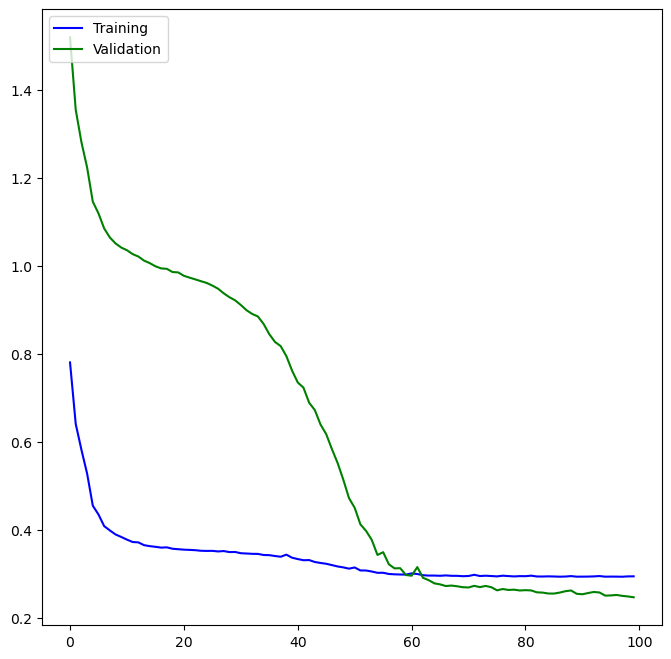

In [874]:
tr_losses=[]
val_losses=[]

max_iter=100

for epoca in range (max_iter):
    autoencoder.fit(X_train, X_train, epochs=1, validation_data=(X_val, X_val),
                    callbacks=callbacks)
    tr_loss=autoencoder.evaluate(X_train, X_train, verbose=0)
    val_loss=autoencoder.evaluate(X_val, X_val, verbose=0)

    tr_losses.append(tr_loss)
    val_losses.append(val_loss)

    clear_output()
    plt.figure(figsize=(8,8))
    plt.plot(tr_losses, color="blue", label="Training")
    plt.plot(val_losses, color="green", label="Validation")
    plt.legend(loc="upper left")

    plt.show()
    sleep(0.1)




Al aumentar la capacidad del autoencoder mediante una capa intermedia de 8 neuronas y usar activaciones ReLU, el modelo logró reducir significativamente tanto la pérdida de entrenamiento como la de validación. La convergencia entre ambas curvas sugiere que el modelo aprendió una representación latente útil del comportamiento normal y generaliza adecuadamente a datos normales no vistos.

In [875]:
from tensorflow.keras.models import load_model

#Cargamos el mejor modelo 
model_autoencoder=load_model(ruta_modelo_autoencoding)


In [876]:
## En este caso vamos a calcular el mse para todo el dataset pero previo a eso tenemos que transformar todos los datos 
#Comprobando calidad y rendimiento del modelo 
scaler.set_output(transform="pandas")


y=df["Engine Condition"]
X=df.drop(columns=["Engine Condition"]).copy()
X_std=scaler.transform(X)

X_std.head()


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,PressureSum
0,1.783188,-1.148542,-1.091835,-0.740428,0.005378,0.938311,0.070190,-0.183775,0.179396,-0.872680,-0.045973,-0.042646,-1.140455,0.127993,-1.237013,-1.547164
1,0.291801,1.279760,0.249393,0.370503,-0.054394,-0.466227,1.076066,0.380161,0.512127,0.410645,0.019921,-0.079889,1.269005,-0.180173,-0.516388,0.743862
2,1.295389,-0.529549,-0.005052,-1.001747,2.442108,-0.078138,0.410815,0.797419,-0.319942,1.157514,-0.233607,-0.106953,-0.760285,0.198485,-0.891288,-0.489443
3,2.278984,1.148991,-0.553164,0.355749,-0.580337,-0.863686,2.861404,0.692503,1.911939,0.547721,0.301601,-0.076439,1.229913,-0.189583,-1.418596,0.002437
4,1.547285,0.240036,-0.658918,0.727923,2.053440,0.155466,1.297472,0.219824,1.837023,0.767031,0.135906,-0.012326,-0.021248,-0.204672,-1.023777,-0.264469


In [877]:
X_std.shape

(19535, 16)

In [878]:
print(X_std.columns)

Index(['Engine RPM', 'Lub Oil Pressure', 'Fuel Pressure', 'Coolant Pressure',
       'Lub Oil Temp', 'Coolant Temp', 'RPM_x_OilPressure',
       'RPM_x_FuelPressure', 'RPM_x_CoolantPressure', 'TempDiff',
       'OilFuelPressureRatio', 'CoolantOilPressureRatio', 'OilHealthIndex',
       'CoolantStress', 'OilTempPerRPM', 'PressureSum'],
      dtype='str')


In [879]:
X_std.shape

(19535, 16)

In [880]:
print(model_autoencoder.input_shape)

(None, 16)


In [881]:
#X_std["mse"]=model_autoencoder.evaluate(X_std, X_std, verbose=0)
X_pred=model_autoencoder.predict(X_std, verbose=0)
X_std["mse"] = np.mean((X_std - X_pred) ** 2, axis=1)
X_std["log1p(mse)"]=np.log1p(X_std["mse"])

In [882]:
X_std["Engine Condition"]=y

In [883]:
X_std.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,0.220788,1.070005,-2.698968,-0.571843,0.039905,0.791596,6.009449
Lub Oil Pressure,19535.0,-0.045407,0.994986,-3.259684,-0.809886,-0.183449,0.686481,3.813011
Fuel Pressure,19535.0,-0.080253,0.998944,-2.487118,-0.709330,-0.244474,0.313879,5.159626
Coolant Pressure,19535.0,0.015245,1.032983,-2.309989,-0.717247,-0.152688,0.527032,5.141512
Lub Oil Temp,19535.0,0.091711,1.045355,-2.032425,-0.552585,-0.185865,0.235619,4.102916
Coolant Temp,19535.0,0.041254,0.993245,-2.639851,-0.683989,0.028328,0.759450,18.780454
RPM_x_OilPressure,19535.0,0.115764,1.035729,-2.066762,-0.618872,-0.082238,0.653140,7.846732
RPM_x_FuelPressure,19535.0,0.070424,1.059517,-1.832656,-0.633003,-0.168409,0.499571,9.420048
RPM_x_CoolantPressure,19535.0,0.154603,1.117453,-1.798241,-0.602705,-0.113191,0.620968,10.584365
TempDiff,19535.0,0.002260,1.005425,-17.641670,-0.713928,0.008202,0.703992,3.502472


(array([1.935e+04, 1.380e+02, 2.300e+01, 9.000e+00, 3.000e+00, 6.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 2.000e+00]),
 array([2.20797886e-03, 1.01965940e+00, 2.03711082e+00, 3.05456224e+00,
        4.07201365e+00, 5.08946507e+00, 6.10691649e+00, 7.12436791e+00,
        8.14181933e+00, 9.15927075e+00, 1.01767222e+01]),
 <BarContainer object of 10 artists>)

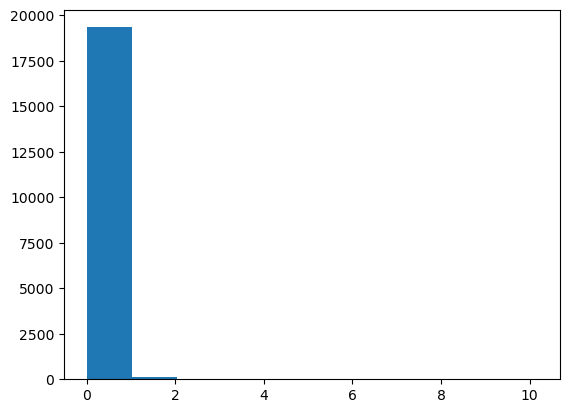

In [884]:
plt.hist(X_std["log1p(mse)"])

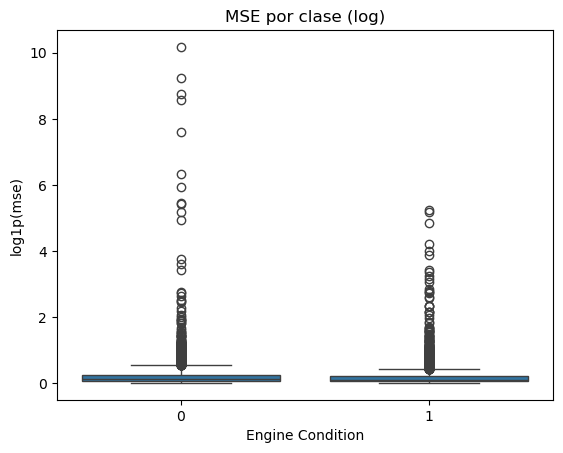

In [885]:
sns.boxplot(
    x=X_std["Engine Condition"],
    y=X_std["log1p(mse)"]
)

plt.title("MSE por clase (log)")
plt.show()

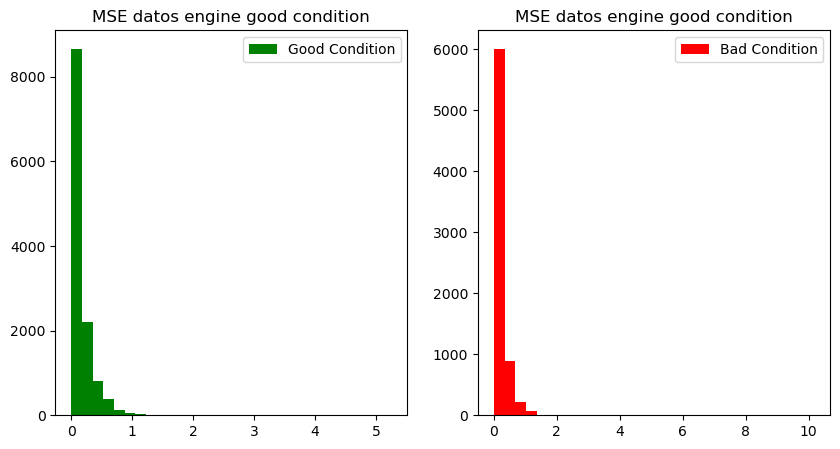

In [886]:
# Ahora vamos a generar una comparacion exploratoria para entender que tan bien esta funcionando el modelo
import matplotlib.pyplot as plt

fig, axes=plt.subplots(1,2, figsize=(10,5))

#Primer Plot
axes[0].hist(X_std[X_std["Engine Condition"]==1]["log1p(mse)"], color="green", bins=30, label="Good Condition")
axes[0].set_title("MSE datos engine good condition")
axes[0].legend()

#segudno Plot
axes[1].hist(X_std[X_std["Engine Condition"]==0]["log1p(mse)"], color="red", bins=30, label="Bad Condition")
axes[1].set_title("MSE datos engine good condition")
axes[1].legend()

plt.show()

In [892]:
mse_normal=X_std[X_std["Engine Condition"]==1].copy()
mse_anormal=X_std[X_std["Engine Condition"]==0].copy()

In [893]:
mse_normal.head()

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,PressureSum,mse,log1p(mse),Engine Condition
5,-0.735776,-1.702434,-0.542131,-0.818464,-0.346381,0.343725,-1.330944,-0.759840,-0.921413,-0.474401,-0.369268,0.009460,-1.666549,0.131694,0.514287,-1.273957,0.066889,0.064747,1
7,2.031086,0.577283,-0.672510,-1.026799,-1.217444,-0.449208,2.018979,0.424177,-0.096248,-0.121786,0.226711,-0.142212,0.751853,0.190615,-1.385830,-0.719160,0.267834,0.237310,1
10,-0.439898,1.731760,-0.950841,-0.772254,0.298026,0.126681,0.606950,-0.871629,-0.772840,0.014223,0.741313,-0.148648,1.650315,0.101448,0.194820,-0.508850,0.025262,0.024948,1
12,-0.016072,-0.538402,-0.101219,0.323130,0.329159,-0.344605,-0.361718,-0.087083,0.255139,0.467571,-0.215163,0.011892,-0.570753,-0.170560,-0.237469,-0.159227,0.019514,0.019326,1
13,1.155446,1.645595,0.818476,-0.383479,-0.565858,1.453935,2.236272,1.554290,0.306219,-1.607261,-0.059478,-0.128034,1.729031,0.028270,-1.035741,1.117216,0.139693,0.130759,1


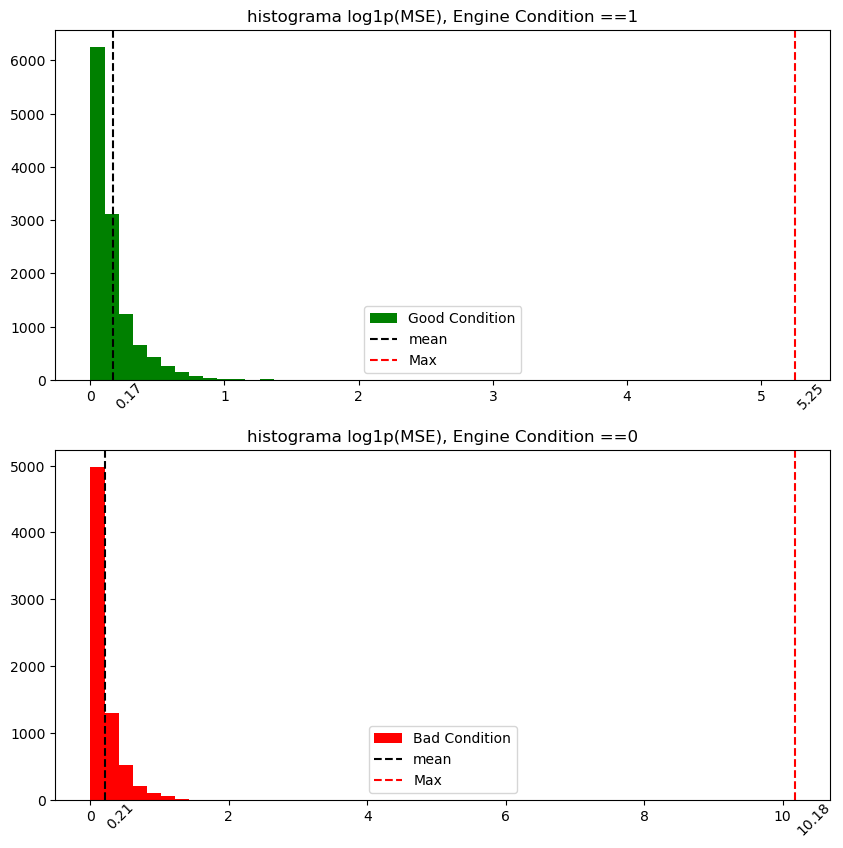

In [948]:
import matplotlib.pyplot as plt

fig, axes=plt.subplots(2,1, figsize=(10,10))
mean_mse_normal=np.mean(mse_normal["log1p(mse)"])
mean_mse_anormal= np.mean(mse_anormal["log1p(mse)"])
#Primer Plot
axes[0].hist(mse_normal["log1p(mse)"], color="green", bins=50, label="Good Condition")
axes[0].axvline(x=mean_mse_normal, color="black", linestyle="--", label="mean")
axes[0].axvline(x=np.max(mse_normal["log1p(mse)"]), color="red", linestyle="--", label="Max")
axes[0].set_title("histograma log1p(MSE), Engine Condition ==1")
axes[0].legend()
axes[0].text(
    mean_mse_normal, 
    plt.ylim()[0]*0.9,   # altura del texto
    f"{mean_mse_normal:.2f}",
    color="black",
    rotation=45,
    verticalalignment="top"
)
axes[0].text(
    np.max(mse_normal["log1p(mse)"]), 
    plt.ylim()[0]*0.9,   # altura del texto
    f"{np.max(mse_normal["log1p(mse)"]):.2f}",
    color="black",
    rotation=45,
    verticalalignment="top"
)
#segudno Plot
axes[1].hist(mse_anormal["log1p(mse)"], color="red", bins=50, label="Bad Condition")
axes[1].axvline(x=mean_mse_anormal, color="black", linestyle="--", label="mean")
axes[1].axvline(x=np.max(mse_anormal["log1p(mse)"]), color="red", linestyle="--", label="Max")
axes[1].set_title("histograma log1p(MSE), Engine Condition ==0")
axes[1].legend()

axes[1].text(
    mean_mse_anormal, 
    plt.ylim()[0]*0.9,   # altura del texto
    f"{mean_mse_anormal:.2f}",
    color="black",
    rotation=45,
    verticalalignment="top"
)
axes[1].text(
    np.max(mse_anormal["log1p(mse)"]), 
    plt.ylim()[0]*0.9,   # altura del texto
    f"{np.max(mse_anormal["log1p(mse)"]):.2f}",
    color="black",
    rotation=45,
    verticalalignment="top"
)

plt.show()

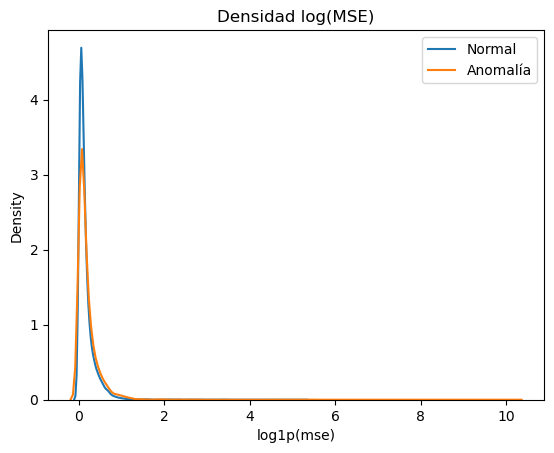

In [896]:
import seaborn as sns

sns.kdeplot(mse_normal["log1p(mse)"], label="Normal")
sns.kdeplot(mse_anormal["log1p(mse)"], label="Anomalía")

plt.legend()
plt.title("Densidad log(MSE)")
plt.show()

In [897]:
mse_normal.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,12317.0,0.001107,0.996799,-2.698968,-0.735776,-0.184003,0.527704,5.741560
Lub Oil Pressure,12317.0,0.000981,0.998501,-3.259684,-0.757436,-0.132386,0.733532,3.813011
Fuel Pressure,12317.0,0.008649,1.004867,-2.469926,-0.622372,-0.165164,0.395153,5.159626
Coolant Pressure,12317.0,-0.003776,1.001694,-2.296850,-0.722715,-0.161535,0.516541,5.141512
Lub Oil Temp,12317.0,0.016783,1.013388,-2.032425,-0.604144,-0.238716,0.174756,4.003960
Coolant Temp,12317.0,0.006031,1.013316,-2.639851,-0.736264,-0.011057,0.735917,18.780454
RPM_x_OilPressure,12317.0,-0.001615,0.987768,-2.066762,-0.696113,-0.194895,0.484260,5.712246
RPM_x_FuelPressure,12317.0,0.008040,1.011010,-1.825570,-0.664562,-0.228355,0.414426,7.406992
RPM_x_CoolantPressure,12317.0,-0.000903,0.997469,-1.786891,-0.671637,-0.231962,0.420026,10.584365
TempDiff,12317.0,0.001830,1.012497,-17.641670,-0.713825,0.008320,0.710749,3.353748


In [898]:
mse_anormal.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,7218.0,0.595657,1.086444,-1.539445,-0.203995,0.427746,1.179436,6.009449
Lub Oil Pressure,7218.0,-0.124565,0.983991,-3.255294,-0.892632,-0.275814,0.619096,3.604358
Fuel Pressure,7218.0,-0.231959,0.970189,-2.487118,-0.844552,-0.381101,0.159881,4.696733
Coolant Pressure,7218.0,0.047703,1.083592,-2.309989,-0.710276,-0.137880,0.545121,4.832434
Lub Oil Temp,7218.0,0.219572,1.085954,-1.722419,-0.455445,-0.094323,0.336168,4.102916
Coolant Temp,7218.0,0.101359,0.955101,-2.516209,-0.600499,0.095882,0.800086,6.433443
RPM_x_OilPressure,7218.0,0.316062,1.083910,-2.062444,-0.467203,0.129300,0.906031,7.846732
RPM_x_FuelPressure,7218.0,0.176878,1.129668,-1.832656,-0.573671,-0.067399,0.639053,9.420048
RPM_x_CoolantPressure,7218.0,0.419962,1.253084,-1.798241,-0.439902,0.142369,0.946271,7.646820
TempDiff,7218.0,0.002994,0.993310,-5.924761,-0.713973,0.008072,0.684680,3.502472
